# MovieLens 32M → a 1M-rating dataset of recent movies

ML-1M's movies stop in 2000. [MovieLens 32M](https://grouplens.org/datasets/movielens/32m/) (GroupLens, 2024) has
ratings up to October 2023, but is 32x bigger than we want. This notebook cuts it down to an ML-1M-sized dataset
of **recent movies** and writes it in the ML-1M format, so every model here runs on it unchanged:

1. keep movies released **2010 or later**
2. of those, keep the **4,000 most-rated** (like ML-1M's ~3,700 movies)
3. keep users with **at least 20 ratings** on them (ML-1M's rule)
4. take users in random order until there are **~1,000,000 ratings**

Input: `data/ml-32m/` (download `ml-32m.zip` from GroupLens and unzip it into `data/`).
Output: `data/ml-32m-recent/` with `ratings.dat` and `movies_wiki.csv` (no Wikipedia plots: titles, genres, year
and the TMDB id). MovieLens may not be redistributed: both folders stay local.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

from genrec.data import Dataset
from genrec.paths import DATA_DIR

SRC, OUT = DATA_DIR / "ml-32m", DATA_DIR / "ml-32m-recent"
MIN_YEAR = 2010          # newest movies only
N_MOVIES = 4000          # most-rated recent movies to keep
MIN_USER_RATINGS = 20    # like ML-1M
TARGET_RATINGS = 1_000_000
SEED = 0

BLUE, INK, INK_2, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": INK_2, "ytick.color": INK_2,
})

## 1. The full MovieLens 32M

In [2]:
movies = pd.read_csv(SRC / "movies.csv")
movies["year"] = movies["title"].str.strip().str.extract(r"\((\d{4})\)$")[0].astype("Int64")
links = pd.read_csv(SRC / "links.csv", usecols=["movieId", "tmdbId"])
ratings = pd.read_csv(SRC / "ratings.csv", dtype={"userId": "int32", "movieId": "int32", "rating": "float32",
                                                 "timestamp": "int64"})
when = pd.to_datetime(ratings["timestamp"], unit="s")
print(f"{len(ratings):,} ratings, {ratings.userId.nunique():,} users, {len(movies):,} movies; "
      f"rated {when.min():%b %Y} - {when.max():%b %Y}; movies up to {movies.year.max()}")

32,000,204 ratings, 200,948 users, 87,585 movies; rated Jan 1995 - Oct 2023; movies up to 2023


## 2. Cut it down

In [3]:
recent = movies.loc[movies["year"] >= MIN_YEAR, "movieId"]
r = ratings[ratings.movieId.isin(recent)]
print(f"movies from {MIN_YEAR}: {len(recent):,} movies, {len(r):,} ratings")

top = r.movieId.value_counts().head(N_MOVIES)
r = r[r.movieId.isin(top.index)]
print(f"{N_MOVIES:,} most-rated: at least {top.min()} ratings each, {len(r):,} ratings")

per_user = r.userId.value_counts()
per_user = per_user[per_user >= MIN_USER_RATINGS]
order = per_user.sample(frac=1, random_state=SEED)          # users in random order
keep = order.index[: int((order.cumsum() <= TARGET_RATINGS).sum())]
r = r[r.userId.isin(keep)].sort_values(["userId", "timestamp"], kind="stable")
print(f"users with >= {MIN_USER_RATINGS} ratings: {len(per_user):,}; sampled {len(keep):,} -> {len(r):,} ratings")

movies from 2010: 35,958 movies, 4,821,916 ratings
4,000 most-rated: at least 69 ratings each, 4,549,679 ratings


users with >= 20 ratings: 44,564; sampled 10,628 -> 999,878 ratings


## 3. Write it in the ML-1M format

In [4]:
kept = movies[movies.movieId.isin(r.movieId.unique())].merge(links, on="movieId", how="left")
# titles must be unique (the LLM answers with them): the few remakes that share a title get their MovieLens id
dup = kept["title"].str.strip().duplicated(keep=False)
kept.loc[dup, "title"] = kept.loc[dup, "title"].str.strip() + " [" + kept.loc[dup, "movieId"].astype(str) + "]"
out_movies = pd.DataFrame({
    "MovieID": kept.movieId, "Title": kept.title.str.strip(),
    "Genres": kept.genres.replace("(no genres listed)", ""), "Year": kept.year, "tmdb_id": kept.tmdbId.astype("Int64"),
})

OUT.mkdir(parents=True, exist_ok=True)
out_movies.to_csv(OUT / "movies_wiki.csv", index=False)
with open(OUT / "ratings.dat", "w") as f:
    for u, m, rating, t in r[["userId", "movieId", "rating", "timestamp"]].itertuples(index=False):
        f.write(f"{u}::{m}::{rating:g}::{t}\n")
print(f"wrote {OUT}: {len(out_movies):,} movies, {len(r):,} ratings ({dup.sum()} duplicate titles renamed)")

wrote data/ml-32m-recent: 4,000 movies, 999,878 ratings (2 duplicate titles renamed)


## 4. The result, next to ML-1M

Loaded with the same `genrec.data.Dataset` every model uses.

In [5]:
ds = Dataset.load(OUT)
ml1m = {"users": 6040, "movies": 3706, "ratings": 1000209, "ratings per user (median)": 96,
        "movie years": "1919-2000", "rated": "2000-2003"}
lengths = ds.sequences.map(len)
when = pd.to_datetime(ds.ratings.Timestamp, unit="s")
pd.DataFrame({"ML-1M": ml1m, "ML-32M recent": {
    "users": len(ds.users), "movies": ds.index.n_cols - 1, "ratings": len(ds.ratings),
    "ratings per user (median)": int(lengths.median()),
    "movie years": f"{int(ds.movies.Year.min())}-{int(ds.movies.Year.max())}",
    "rated": f"{when.min():%Y}-{when.max():%Y}",
}})

,ML-1M,ML-32M recent
users,6040,10628
movies,3706,4000
ratings,1000209,999878
ratings per user (median),96,53
movie years,1919-2000,2010-2023
rated,2000-2003,2009-2023


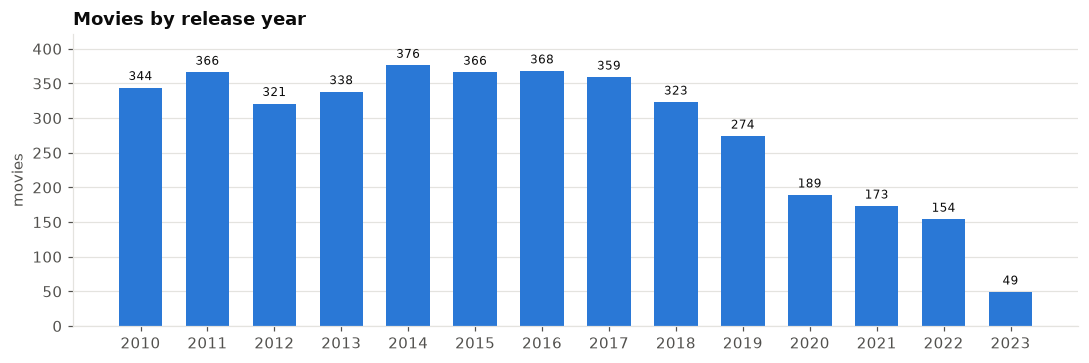

In [6]:
years = ds.movies.Year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 3.4))
b = ax.bar(years.index.astype(int).astype(str), years.values, color=BLUE, width=0.65)
ax.bar_label(b, labels=[f"{v:,}" for v in years.values], padding=3, color=INK, fontsize=8)
ax.set(title="Movies by release year", ylabel="movies")
ax.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", visible=False)
ax.margins(y=0.12)
fig.tight_layout()